# Project Context: Review Summarization Service

This project focuses on developing a service designed to help businesses quickly obtain useful summaries of their customer reviews collected from various websites. Such a service enables business clients to answer key questions, such as:

- **What are the most important factors driving negative reviews?**
- **Did a recent policy change improve our customer feedback?**

## Imports 

In [1]:
import nltk # imports the natural language toolkit
nltk.download('punkt')
nltk.download('stopwords')
import pandas as pd
import numpy as np
import string
import plotly
import matplotlib.pyplot as plt
from nltk.stem import PorterStemmer


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\newUs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\newUs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load data from data-set

In [2]:
# LOADING THE DATASET AND SEEING THE DETAILS
# If your computer can handle the entire dataset remove the nrows=5000
data = pd.read_csv(r'data\sdata.csv', nrows=5000)
data.head()

,review_id,user_id,business_id,stars,date,text,useful,funny,cool
0,vkVSCC7xljjrAI4UGfnKEQ,bv2nCi5Qv5vroFiqKGopiw,AEx2SYEUJmTxVVB18LlCwA,5,2016-05-28,Super simple place but amazing nonetheless. It...,0,0,0
1,n6QzIUObkYshz4dz2QRJTw,bv2nCi5Qv5vroFiqKGopiw,VR6GpWIda3SfvPC-lg9H3w,5,2016-05-28,Small unassuming place that changes their menu...,0,0,0
2,MV3CcKScW05u5LVfF6ok0g,bv2nCi5Qv5vroFiqKGopiw,CKC0-MOWMqoeWf6s-szl8g,5,2016-05-28,Lester's is located in a beautiful neighborhoo...,0,0,0
3,IXvOzsEMYtiJI0CARmj77Q,bv2nCi5Qv5vroFiqKGopiw,ACFtxLv8pGrrxMm6EgjreA,4,2016-05-28,Love coming here. Yes the place always needs t...,0,0,0
4,L_9BTb55X0GDtThi6GlZ6w,bv2nCi5Qv5vroFiqKGopiw,s2I_Ni76bjJNK9yG60iD-Q,4,2016-05-28,Had their chocolate almond croissant and it wa...,0,0,0


In [3]:
AllReviews = data['text']
AllReviews.head()

0    Super simple place but amazing nonetheless. It...
1    Small unassuming place that changes their menu...
2    Lester's is located in a beautiful neighborhoo...
3    Love coming here. Yes the place always needs t...
4    Had their chocolate almond croissant and it wa...
Name: text, dtype: object

# 1. Question about dataset
What are the most frequent words or topics mentioned in customer reviews for this business?

In [4]:
from collections import Counter


# Combine all reviews text
all_reviews_text = " ".join(data['text'].astype(str).tolist())

# Tokenize the text into words
words = nltk.word_tokenize(all_reviews_text.lower())

# Remove punctuation and stopwords
words = [w for w in words if w.isalpha()]  # Keep only alphabetic words

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

# Count word frequencies
word_freq = Counter(filtered_words)
most_common_words = word_freq.most_common(10)

print("Most common words in customer reviews:")
for word, freq in most_common_words:
    print(f"{word}: {freq}")

Most common words in customer reviews:
place: 2972
good: 2870
food: 2689
one: 2310
like: 2250
great: 2083
would: 1998
time: 1967
get: 1871
really: 1842


In [5]:
# Print text of first Yelp review
AllReviews[0]

# sentence tokenization
sentences = nltk.sent_tokenize(AllReviews[0])
for sentence in sentences:
    print("\n" + sentence)
    print()



Super simple place but amazing nonetheless.


It's been around since the 30's and they still serve the same thing they started with: a bologna and salami sandwich with mustard.


Staff was very helpful and friendly.



# 2. Question about dataset

- Analysis of the sizes of reviews

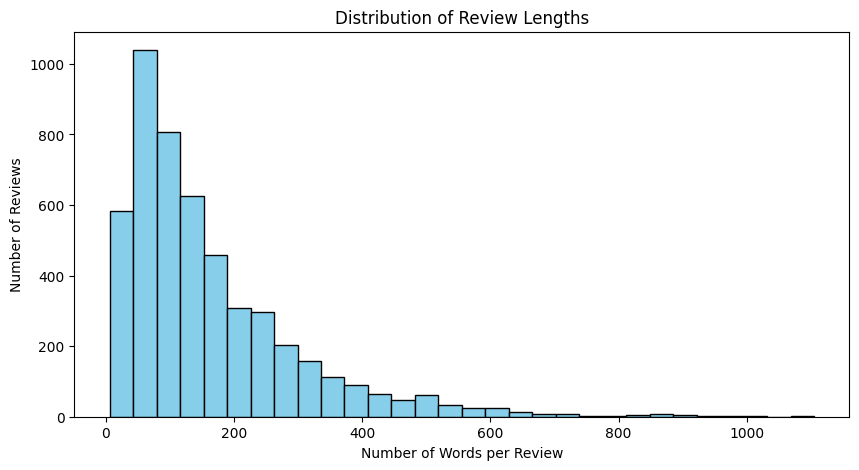

Shortest review (6 words):
Bon  Muffin !!! Succulent

Longest review (1105 words):
First things first - I am a road cyclist and a spin class junkie (though I prefer the term "aficionado"). Last week, I posted the following to my Facebook status after yet another predictably boring YMCA spin class, "If 90+% of your class has us out of the saddle or doing ridiculous 'jumps', it's not a cycle class. It's an elliptical class. It is also a waste of my time."

After reading that Facebook status, a friend of mine sent me an invitation to the "Open House Week" at Flywheel Ballantyne. I had never heard of Flywheel before, but my friend said they were offering free classes all week and suggested we try them. I wrote her back saying, "Given what they charge, I'm interested in seeing how - if at all - this is different from a general spin class." Frankly, having spent hundreds of hours in YMCA spin classes over the past 3 years, I was not expecting much.

I told her as I gripped the handrail down 

In [6]:



# Calculate review lengths (number of words per review)
review_lengths = data['text'].apply(lambda x: len(nltk.word_tokenize(x)))

# Find the shortest review
min_length = review_lengths.min()
shortest_review = data['text'][review_lengths.idxmin()]

# Find the longest review
max_length = review_lengths.max()
longest_review = data['text'][review_lengths.idxmax()]

# Plot histogram of review lengths
plt.figure(figsize=(10,5))
plt.hist(review_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words per Review')
plt.ylabel('Number of Reviews')
plt.show()

# Print results
print("Shortest review ({} words):\n{}".format(min_length, shortest_review))
print("\nLongest review ({} words):\n{}".format(max_length, longest_review))


# 3. Question about dataset

Word cloud

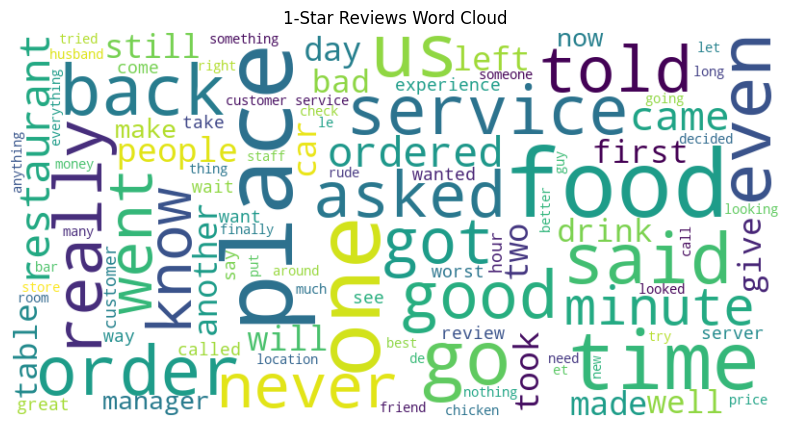

In [7]:
from wordcloud import WordCloud


def word_cloud_rating(data, star_value):
    filtered_reviews = data[data['stars'] == star_value]
    text = ' '.join(filtered_reviews['text'])
    wordcloud = WordCloud(max_font_size=100, max_words=100, background_color="white", width=800, height=400).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{star_value}-Star Reviews Word Cloud")
    plt.show()

word_cloud_rating(data, 1)


# 4. Question about dataset

The word "good" seems to appear quite frequently in the negative reviews. Investigate why that is and come up with a reasonable explanation. 

# Answer:

- So, the frequent appearance of "good" in negative reviews is mainly due to its use inside sentences that express contrast or disappointment, rather than as pure praise.

# 5. Question about dataset

Find all the high-frequency (top 1%) and low-frequency (bottom 1%) words in the reviews overall.

In [8]:

import re
import unicodedata
from collections import Counter
from nltk.corpus import stopwords

# Ensure you have NLTK stopwords downloaded
# import nltk
# nltk.download('stopwords')

# Load your data
# data = pd.read_csv('sdata.csv')

def preprocess_text(text):
    # Remove accents
    text = ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )
    # Lowercase
    text = text.lower()
    # Remove numbers and non-alphabetical characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize and remove stop words
    stop_words = set(stopwords.words('english'))
    words = [w for w in text.split() if w not in stop_words]
    return words

# Combine and preprocess all reviews
all_reviews = ' '.join(data['text'])
words = preprocess_text(all_reviews)

# Count frequencies
word_counts = Counter(words)
total_unique_words = len(word_counts)
top_1pct = int(np.ceil(total_unique_words * 0.01))
bottom_1pct = int(np.ceil(total_unique_words * 0.01))

# Top 1% most frequent words
high_freq_words = word_counts.most_common(top_1pct)
# Bottom 1% least frequent words
low_freq_words = word_counts.most_common()[:-bottom_1pct-1:-1]

print("Top 1% most frequent words (after preprocessing):", high_freq_words)
print("Bottom 1% least frequent words (after preprocessing):", low_freq_words)


Top 1% most frequent words (after preprocessing): [('place', 2959), ('good', 2855), ('food', 2675), ('one', 2291), ('like', 2243), ('great', 2076), ('time', 1959), ('get', 1872), ('really', 1836), ('would', 1767), ('back', 1620), ('also', 1618), ('service', 1601), ('go', 1592), ('well', 1291), ('im', 1255), ('dont', 1236), ('nice', 1195), ('little', 1167), ('ordered', 1144), ('ive', 1085), ('even', 1076), ('us', 1023), ('try', 980), ('always', 972), ('came', 961), ('menu', 935), ('pretty', 935), ('love', 932), ('order', 922), ('got', 918), ('much', 894), ('people', 886), ('could', 882), ('didnt', 882), ('first', 863), ('de', 863), ('two', 857), ('never', 844), ('staff', 835), ('restaurant', 833), ('chicken', 816), ('come', 811), ('bar', 793), ('best', 788), ('make', 783), ('went', 780), ('definitely', 771), ('friendly', 764), ('made', 734), ('know', 734), ('delicious', 732), ('sure', 704), ('around', 703), ('think', 700), ('though', 678), ('right', 670), ('way', 657), ('going', 655), (

# 6. Question about dataset
Write a function called top_k_ngrams(word_tokens, n, k) for printing out the top k n-grams. 

In [15]:
from collections import Counter
from nltk.util import ngrams

def top_k_ngrams(word_tokens, n, k):
    n_grams = ngrams(word_tokens, n)
    ngram_freq = Counter(n_grams)
    top_k = ngram_freq.most_common(k)
    for ngram, freq in top_k:
        print(f"{' '.join(ngram)}: {freq}")

# Example for the first 1000 reviews:
first_1000 = ' '.join(data['text'][:1000]).lower()
words = nltk.word_tokenize(first_1000)
print("Top 10 1-grams:")
top_k_ngrams(words, 1, 10)

print("\nTop 10 2-grams:")
top_k_ngrams(words, 2, 10)

print("\nTop 10 3-grams:")
top_k_ngrams(words, 3, 10)


Top 10 1-grams:
.: 10808
the: 8623
,: 6198
i: 5953
and: 5587
a: 4846
to: 4403
it: 3333
was: 3069
of: 2876

Top 10 2-grams:
. i: 1946
. the: 1507
, but: 867
. it: 725
it 's: 694
it was: 643
of the: 603
, and: 603
in the: 536
i was: 535

Top 10 3-grams:
. it 's: 241
. it was: 194
, but i: 168
. i 've: 163
. i was: 143
i do n't: 131
. i 'm: 120
it 's a: 117
. the food: 105
, but it: 103


# 7.1 Question about dataset
Filter out all of the stop words in the first review of the Yelp review data and print out your answer.


In [11]:
from nltk.corpus import stopwords

first_review = data['text'][0]
words = nltk.word_tokenize(first_review.lower())
stop_words = set(stopwords.words('english'))

filtered_words = [w for w in words if w.isalpha() and w not in stop_words]
found_stopwords = [w for w in words if w in stop_words]

print("Filtered review (no stopwords):")
print(filtered_words)

print("\nStopwords found in review:")
print(found_stopwords)


Filtered review (no stopwords):
['super', 'simple', 'place', 'amazing', 'nonetheless', 'around', 'since', 'still', 'serve', 'thing', 'started', 'bologna', 'salami', 'sandwich', 'mustard', 'staff', 'helpful', 'friendly']

Stopwords found in review:
['but', 'it', 'been', 'the', 'and', 'they', 'the', 'same', 'they', 'with', 'a', 'and', 'with', 'was', 'very', 'and']


# 7.2 Question about dataset

In [16]:
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter

def top_k_ngrams(corpus, n=2, k=10):
    stop_words = set(stopwords.words('english'))
    # Tokenize and remove stop words for all sentences
    filtered_tokens = []
    for doc in corpus:
        tokens = [word for word in doc.lower().split() if word.isalpha() and word not in stop_words]
        filtered_tokens.extend(tokens)
    # Generate n-grams
    n_grams = list(ngrams(filtered_tokens, n))
    # Count n-grams
    n_grams_freq = Counter(n_grams)
    # Get the k most common n-grams
    return n_grams_freq.most_common(k)


# 8.1 Question about dataset

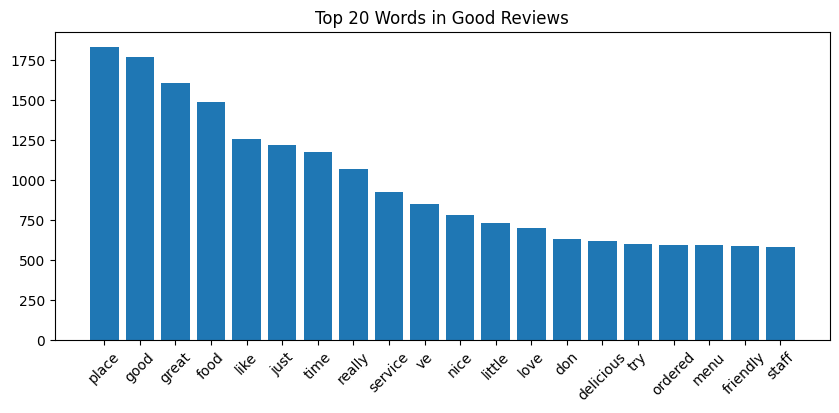

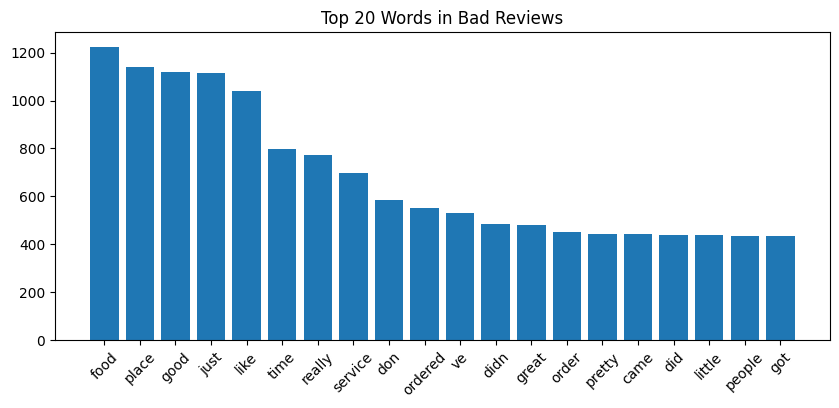

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Split the reviews by their star ratings
good_reviews = data[data['stars'] > 3]['text']
bad_reviews = data[data['stars'] <= 3]['text']

def plot_top_words(corpus, n=20, title="Top Words"):
    vec = CountVectorizer(stop_words='english', max_features=n)
    X = vec.fit_transform(corpus)
    words = vec.get_feature_names_out()
    freqs = X.sum(axis=0).A1
    sorted_idx = freqs.argsort()[::-1]
    plt.figure(figsize=(10,4))
    plt.bar([words[i] for i in sorted_idx], [freqs[i] for i in sorted_idx])
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_top_words(good_reviews, 20, "Top 20 Words in Good Reviews")
plot_top_words(bad_reviews, 20, "Top 20 Words in Bad Reviews")


# 8.2 Question about dataset

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_n_words(corpus, n=20, k=2):
    vec = CountVectorizer(ngram_range=(k, k), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Top 20 bigrams and trigrams for good reviews
top_20_bigrams_good = get_top_n_words(good_reviews, 20, 2)
top_20_trigrams_good = get_top_n_words(good_reviews, 20, 3)
print("Top 20 bigrams in good reviews:", top_20_bigrams_good)
print("\nTop 20 trigrams in good reviews:", top_20_trigrams_good)

# Top 20 bigrams and trigrams for bad reviews
top_20_bigrams_bad = get_top_n_words(bad_reviews, 20, 2)
top_20_trigrams_bad = get_top_n_words(bad_reviews, 20, 3)
print("\nTop 20 bigrams in bad reviews:", top_20_bigrams_bad)
print("\nTop 20 trigrams in bad reviews:", top_20_trigrams_bad)


Top 20 bigrams in good reviews: [('really good', np.int64(130)), ('customer service', np.int64(120)), ('make sure', np.int64(117)), ('highly recommend', np.int64(115)), ('ice cream', np.int64(107)), ('staff friendly', np.int64(102)), ('great place', np.int64(99)), ('las vegas', np.int64(96)), ('pretty good', np.int64(87)), ('feel like', np.int64(80)), ('food good', np.int64(70)), ('love place', np.int64(69)), ('great service', np.int64(68)), ('service great', np.int64(67)), ('food great', np.int64(63)), ('really enjoyed', np.int64(61)), ('great food', np.int64(60)), ('happy hour', np.int64(60)), ('good food', np.int64(59)), ('recommend place', np.int64(58))]

Top 20 trigrams in good reviews: [('great customer service', np.int64(22)), ('sweet potato fries', np.int64(18)), ('food really good', np.int64(16)), ('staff friendly helpful', np.int64(15)), ('service great food', np.int64(15)), ('highly recommend place', np.int64(15)), ('definitely recommend place', np.int64(13)), ('love love lo

# 9.1 Question about dataset

You may have noticed that many of the important "bad" bigrams included the words "like" or "just" but didn't seem very informative (e.g. "felt like", "food just").
Give some ideas of how to use this sort of observation in future pre-processing of reviews, based on the pre-processing ideas we have already studied.

## Answer:

When we notice that bigrams like "felt like" or "food just" are frequent in negative reviews but do not provide much relevant information by themselves, we can consider additional pre-processing steps. For example, we could:

- Remove or filter out uninformative bigrams that consistently do not add value for sentiment or topic analysis.

- Expand our analysis to include surrounding context, such as trigrams or window-based phrase extraction, to capture more meaningful expressions.

# 9.2 Question about dataset

Building on the previous question, we note that most of the most important complaints and compliments can't be completely observed by looking at bigrams or
trigrams. This can often be fixed by small modifications. Do the following:
1. Write down a complaint that is unlikely to be (completely) picked up by bigram analysis. Hint: what might you write if your hamburger was served cold?
- "My hamburger was cold when it arrived."

2. Write down a processing step that would fix this problem. Try to find a solution that would work for several similar problems without additional human
input.
- One possible processing step could be to implement a rule-based system that identifies and extracts complaints about food temperature based on keywords like "cold", "hot", "warm", etc. This system could also consider the context of the review to better understand the sentiment being expressed.

## Answer:

Example complaint unlikely to be detected by bigram analysis:
"My hamburger was served cold and the cheese wasn't even melted."

Processing step to address this problem:
We could implement phrase-level or clause-level extraction by using syntactic parsing (such as dependency parsing) to identify and group together complaint phrases. Another approach could be to combine n-gram analysis with key adjective-noun pairs and verb-object pairs, allowing detection of issues like "served cold" or "wasn't melted".
This method would generalize to similar complaints (e.g., "fries were soggy", "pizza arrived late") without requiring manual labeling, by capturing common complaint structures and associating them with sentiment or topics.